# Seller Analytics
The objective of this notebook is to evaluate seller performance by analyzing revenue contribution, order fulfillment, delivery efficiency, geographic distribution, and seller activity. These insights help identify high-performing sellers and opportunities to improve marketplace operations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
orders = pd.read_csv("../data/engineered/orders_engineered.csv")

orderitems = pd.read_csv("../data/engineered/orderitems_engineered.csv")

sellers = pd.read_csv("../data/engineered/sellers_engineered.csv")

In [3]:
orders.shape, orderitems.shape, sellers.shape

((99441, 14), (112650, 7), (3095, 4))

## Top Sellers by Revenue

In [4]:
seller_sales = (
    orderitems
    .merge(
        sellers,
        on="seller_id"
    )
)

seller_revenue = (
    seller_sales
    .groupby("seller_id")
    .agg(
        Revenue=("price","sum")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
    .head(10)
)

seller_revenue

,Revenue
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
53243585a1d6dc2643021fd1853d8905,222776.05
4a3ca9315b744ce9f8e9374361493884,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,194042.03
7c67e1448b00f6e969d365cea6b010ab,187923.89
7e93a43ef30c4f03f38b393420bc753a,176431.87
da8622b14eb17ae2831f4ac5b9dab84a,160236.57
7a67c85e85bb2ce8582c35f2203ad736,141745.53
1025f0e2d44d7041d6cf58b6550e0bfa,138968.55


<Figure size 1200x600 with 0 Axes>

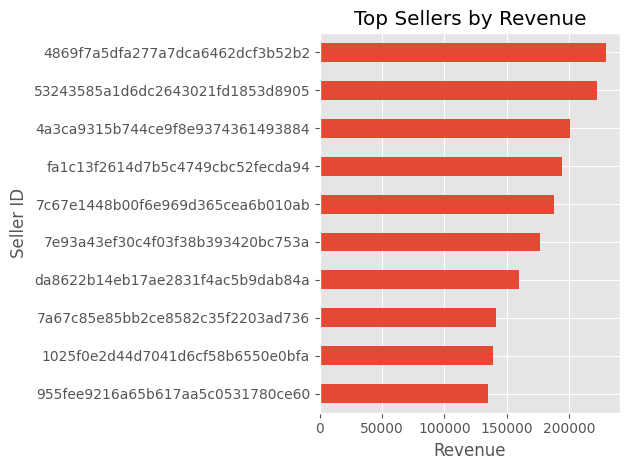

In [5]:
plt.figure(figsize=(12,6))

seller_revenue.sort_values("Revenue").plot(
    kind="barh",
    legend=False
)

plt.title("Top Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

A small group of sellers contributes a substantial share of marketplace revenue. Monitoring these high-performing sellers is essential for maintaining platform growth and strengthening strategic partnerships.

## Seller Order Volume

In [6]:
seller_orders = (
    seller_sales
    .groupby("seller_id")
    .agg(
        TotalOrders=("order_id","nunique")
    )
    .sort_values(
        by="TotalOrders",
        ascending=False
    )
    .head(10)
)

seller_orders

,TotalOrders
seller_id,
6560211a19b47992c3666cc44a7e94c0,1854
4a3ca9315b744ce9f8e9374361493884,1806
cc419e0650a3c5ba77189a1882b7556a,1706
1f50f920176fa81dab994f9023523100,1404
da8622b14eb17ae2831f4ac5b9dab84a,1314
955fee9216a65b617aa5c0531780ce60,1287
7a67c85e85bb2ce8582c35f2203ad736,1160
ea8482cd71df3c1969d7b9473ff13abc,1146
4869f7a5dfa277a7dca6462dcf3b52b2,1132


<Figure size 1200x600 with 0 Axes>

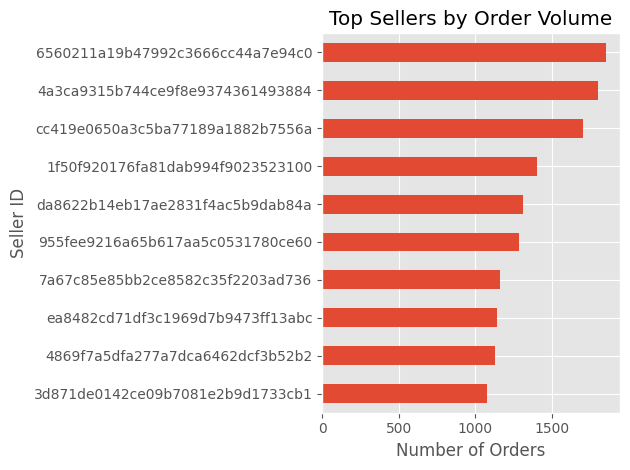

In [7]:
plt.figure(figsize=(12,6))

seller_orders.sort_values("TotalOrders").plot(
    kind="barh",
    legend=False
)

plt.title("Top Sellers by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

High-order-volume sellers play a critical role in marketplace operations. Consistently monitoring their performance helps ensure reliable fulfillment capacity and customer satisfaction.

## Seller Distribution by State

In [8]:
seller_states = (
    sellers["seller_state"]
    .value_counts()
    .head(10)
)

seller_states

SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: seller_state, dtype: int64

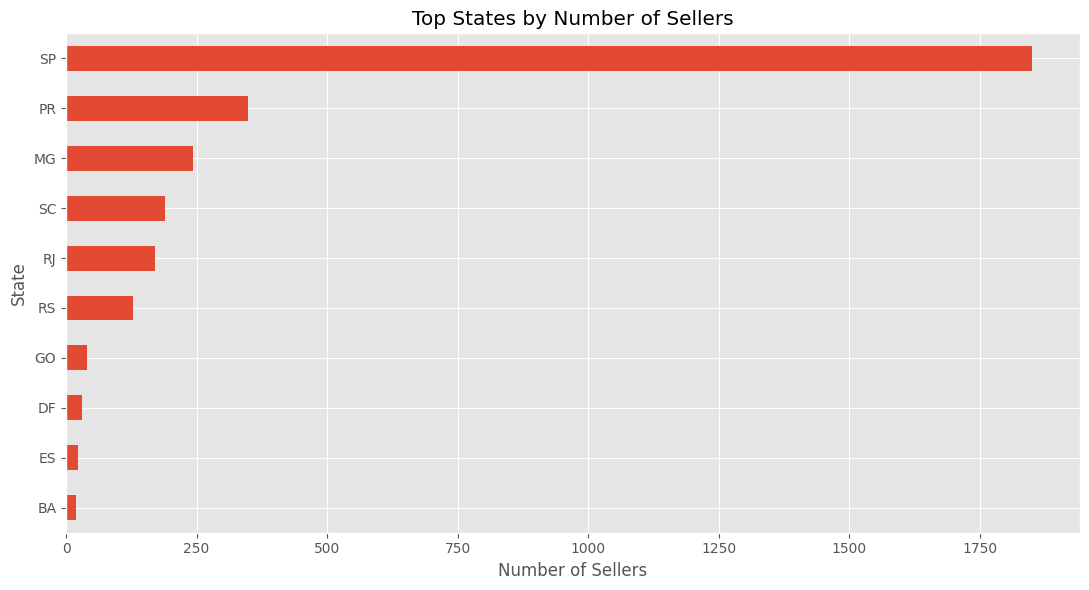

In [9]:
plt.figure(figsize=(11,6))

seller_states.sort_values().plot(
    kind="barh"
)

plt.title("Top States by Number of Sellers")
plt.xlabel("Number of Sellers")
plt.ylabel("State")

plt.tight_layout()

plt.show()

Seller activity is concentrated in a few states, indicating that marketplace supply is regionally clustered. Expanding seller acquisition in underrepresented states can improve geographic coverage and delivery efficiency.

## Average Revenue per Seller

In [10]:
average_revenue = (
    seller_sales
    .groupby("seller_id")
    .agg(
        TotalRevenue=("price", "sum")
    )
)

average_revenue_value = average_revenue["TotalRevenue"].mean()

print(f"Average Revenue per Seller: R$ {average_revenue_value:,.2f}")

Average Revenue per Seller: R$ 4,391.48


The average revenue per seller provides a benchmark for evaluating seller performance and identifying opportunities to improve marketplace productivity.

## Seller Revenue Distribution

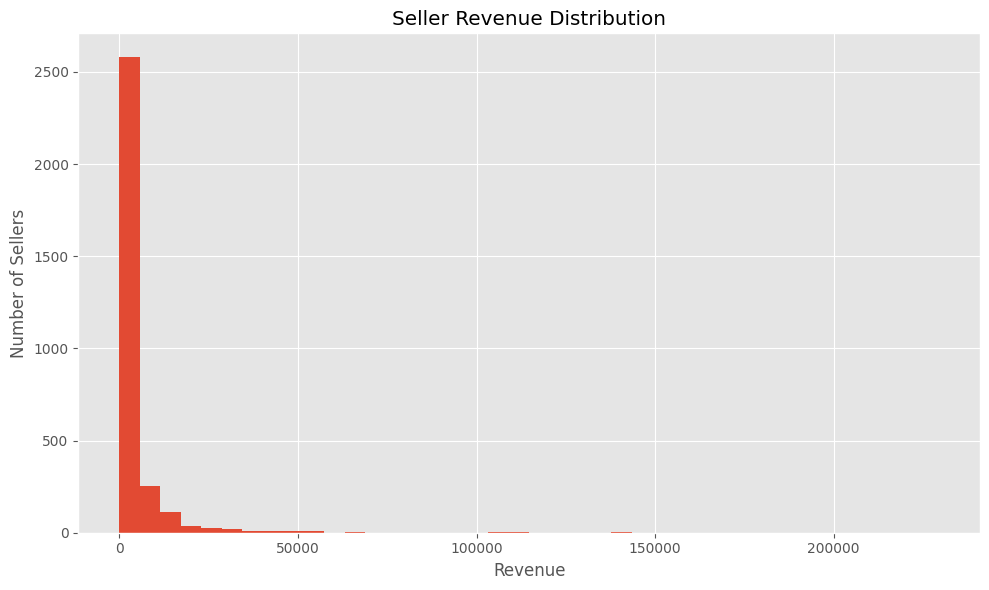

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    average_revenue["TotalRevenue"],
    bins=40
)

plt.title("Seller Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Sellers")

plt.tight_layout()

plt.show()

Seller revenue is unevenly distributed across the marketplace. While many sellers generate modest revenue, a relatively small group of sellers contributes a substantial share of overall marketplace sales.

# Key Insights

- Marketplace revenue is concentrated among a relatively small number of sellers.
- Order volume varies significantly across sellers.
- Seller distribution is geographically concentrated.
- Revenue distribution indicates opportunities to improve seller performance across the marketplace.

# Business Recommendations

- Develop retention programs for high-performing sellers.
- Support low-performing sellers through training and performance insights.
- Expand seller onboarding in regions with limited marketplace coverage.
- Monitor seller performance regularly using revenue and order volume KPIs.